<table style="float:left">
    <tr>
        <td>
            <img src="emlyon.png" style="height:60px; float:left; padding-right:10px; margin-top:5px" />
            <img src="harbin.png" style="height:65px; float:left; padding-right:10px; margin-top:4px" />
        </td>
        <td style="padding-bottom:10px;">
            <h1 style="border-bottom: 1px solid #eeeeee;"> Object Oriented Programming: Python BootCamp </h1>
            <span style="display:inline-block; margin-top:-15px;">HIT-emlyon BSc Program <br/>
            Harbin | © Imène BRIGUI | Saeed VARASTEH
            </span>
        </td>
    </tr>
</table>

<div class="alert-info" style="border-bottom: solid 1px lightgray; background-color:#ece4f5;">
    <img src="assignment.png" style="height:60px; float:left; padding-right:10px;" />
    <span style="font-weight:bold; color:#8966b0">
        <h4 style="padding-top:25px;"> EXERCISES </h4>
    </span>
</div>

### Exercises - Covid

---

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---

<div style="color:gray; background-color:#eeeeee">
    Covid data | France
</div>

You are given a file named __dailydata-covid-fr.csv__.

This file contains data from **Sante Publique France** giving the daily numbers of 4 different categories of people: 

- Daily number of newly hospitalized persons,
- Daily number of newly released persons,
- Daily number of newly deceased persons,
- Daily number of new intensive care admissions.

<br/>

__Question 00__
Read the file into a Pandas `DataFrame` and print the first 3 rows of data.

In [53]:
df = pd.read_csv('dailydata-covid-fr.csv') # your_code

__Question 00__ Check the dimensions. How many rows and columns do you have in the data set? 

In [54]:
# your_code
df.shape

(21816, 6)

__Question 01__
Check for missing values and delete the rows with missing values if you have any.

In [55]:
# your_code
df.dropna()

df.isnull().sum()



dep           0
jour          0
incid_hosp    0
incid_rea     0
incid_dc      0
incid_rad     0
dtype: int64

__Question 02__
Change column names as:

- "jour" to "date" 
- "incid_hosp" to "hospitalized "	
- "incid_rea to "released" 	
- "incid_dc to "deceased"
- "incid_rad" to "intensive_care"

In [56]:
# your_code
renamed_columns = {"jour" : "date",
                   "incid_hosp" : "hospitalized",
                   "incid_rea" : "released",
                   "incid_dc" : "deceased",
                   "incid_rad" : "intensive_care"}
df.rename(columns = renamed_columns, inplace = True)
df.head(2)

,dep,date,hospitalized,released,deceased,intensive_care
0,01,2020-03-19,1,0,0,0
1,01,2020-03-20,0,0,0,1


__Question 03__ Change the type of the __date__ column to datetime.

<span style="color:crimson">Hint:</span> You can use the `pd.to_datetime()` function for this.

In [57]:
# your_code
df['date'] = pd.to_datetime(df['date'])
df.head(3)

,dep,date,hospitalized,released,deceased,intensive_care
0,01,2020-03-19,1,0,0,0
1,01,2020-03-20,0,0,0,1
2,01,2020-03-21,3,0,0,0


__Question 04__ In this data set, we have data from what time period?

<span style="color:crimson">Hint:</span> Find the minimum and maximum __date__ values.

In [58]:
# your_code
df['date'].max(), df['date'].min()

(Timestamp('2020-10-20 00:00:00'), Timestamp('2020-03-19 00:00:00'))

__Question 05__ 
We have data from which departments in this dataset?

<span style="color:crimson">Hint:</span> Find the unique values we have in the __dep__ column.

In [72]:
# your_code
df["dep"].unique()

<StringArray>
[ '01',  '02',  '03',  '04',  '05',  '06',  '07',  '08',  '09',  '10',
 ...
  '93',  '94',  '95',  '2A',  '2B', '971', '972', '973', '974', '976']
Length: 101, dtype: str

__Question 05-1__ How many different deparmanets do we have? 

In [75]:
# your_code
len(df["dep"].unique())

101

---

__Question 06__
Write a code to give the total number of hospitalized persons per department.

<span style="color:crimson">Hint:</span> You can use the `groupby()` function for this.

In [61]:
# your_code
df.groupby("dep")["hospitalized"].sum()

dep
01      858
02     1720
03      448
04      231
05      253
       ... 
971     844
972     268
973    1919
974     544
976     519
Name: hospitalized, Length: 101, dtype: int64

__Question 07__ From the results of the previous step, create a new dataframe containing the columns 'dep' and 'total' as the department code and the total number of hospitalized persons per department. Name this dataframe as __df_dep__

The new dataframe should look like:

|    | dep | total |
| --- | --- | --- |
| __0__ | 01  | 858 |
| __1__ | 02  | 1720 |
| ... | ...  | ... | 
| __100__ | 976  | 519 |

<span style="color:crimson">Hint:</span> You can use the `reset_index()` function for this.

In [81]:
# your_code
df_dep = df.groupby("dep")["hospitalized"].sum().reset_index(name = "total")

__Question 08__ Sort __df_dep__ DataFrame in descending order by column __total__.

In [83]:
# your_code
df_dep = df_dep.sort_values("total", ascending = False)
df_dep

,dep,total
75,75,11420
92,92,8088
12,13,8041
94,94,7930
93,93,7367
...,...,...
79,79,149
21,23,148
15,16,138
8,09,83


__Question 09__ Select the top 5 rows of the __df_dep__ dataframe and create a bar plot where the x values are the top 5 department codes and the y values are the total number of hospitalizations in those departments.

Your output should look like this:

<div>
<img style="" src="deps.png" />
</div>

<span style="color:crimson">Hint:</span> I used the seaborn `barplot()` function to create the plot.

<Axes: xlabel='dep'>

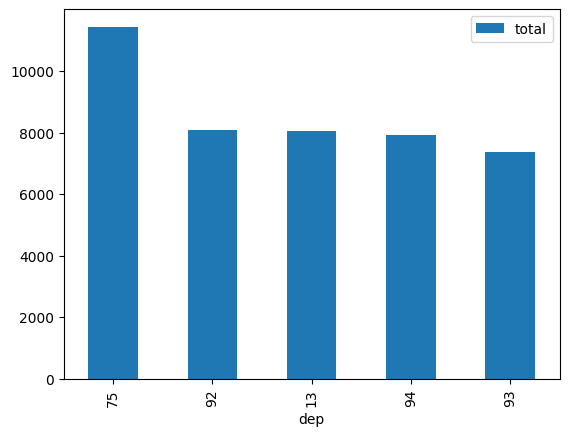

In [84]:
# your_code
df_dep_top5 = df_dep.head()
df_dep_top5.plot( kind = "bar", x = "dep", y = "total")

---

__Question 10__ Using the original dataframe __df__, select all rows where the department is Rhône (69). Name this new DataFrame __df_rhone__.

<span style="color:crimson">Hint:</span> Check columns types if you are not getting what you expect!

In [85]:
# your_code
mask = df["dep"] == "69"
df_rhone = df[mask]
df_rhone.head()

,dep,date,hospitalized,released,deceased,intensive_care
14472,69,2020-03-19,244,28,17,46
14473,69,2020-03-20,32,9,2,11
14474,69,2020-03-21,71,7,2,4
14475,69,2020-03-22,56,9,6,10
14476,69,2020-03-23,109,22,7,8


__Question 11__ Creates a line chart using __df_rhone__ where the x values are dates and the y values are the number of deceased.

Your output should look like this:

<br/>
<div>
<img style="width:80%" src="rhones.png" />
</div>

<span style="color:crimson">Hint:</span> I used the seaborn `lineplot()` function to create the plot.

<Axes: xlabel='date', ylabel='deceased'>

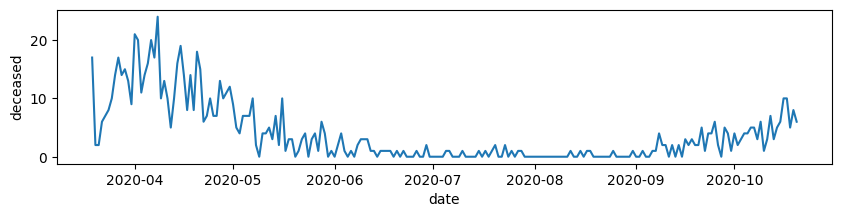

In [88]:
# your_code
import seaborn as sns
plt.figure(figsize=(10,2));
sns.lineplot( data = df_rhone , x = "date" , y = "deceased")

---